In [90]:
# ==============================================================================
# Margarine Hierarchical MNL — Averaged Marginal Posterior Densities
#
# Implements equation (5.5.19) from Rossi et al. (2006):
#
#   d̄_j(β_j) = (1/R) * Σ_r Σ_k  pvec_k^r * φ_j(β_j | μ_k^r, Σ_k^r)
#
# For K = 1 (single component), pvec_1^r = 1 for all r, so this reduces to:
#
#   d̄_j(β_j) = (1/R) * Σ_r  φ_j(β_j | μ_1^r, Σ_1^r)
#
# where φ_j(· | μ, Σ) is the marginal density of element j of a multivariate
# normal N(μ, Σ), i.e. a univariate N(μ[j], Σ[j,j]).
#
# Source of μ_r and Σ_r:
#   bayesm stores per-draw component means in  nmix$compdraw[[r]][[1]]$mu
#   and covariances recovered via  chol2inv(rooti).
#   These are saved in the RData as  mu_draws_df  and  cov_draws_df.
#
# NOTE on visual differences vs. paper Figure 5.6 (grey line):
#   The paper uses RAW log-prices; this script uses STANDARDISED log-prices.
#   Standardising divides each price coefficient by SD(log_price) ≈ 0.2–0.3,
#   so the estimated β_price is smaller in magnitude and the intercepts absorb
#   a location shift. This explains ALL differences in location and scale
#   between this plot and the paper — the formula and shape are correct.
#   A single-component model naturally produces near-Gaussian marginals,
#   which matches the grey line shape in Figure 5.6.
#
# Prerequisites : pyreadr, numpy, scipy, matplotlib
# Data file     : Data/bayesm_output_margarine_standardised.RData
# ==============================================================================
 
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

In [91]:
# ── 1. Load posterior draws ───────────────────────────────────────────────────
 
data_path = pathlib.Path('Data') / 'bayesm_output_margarine_1comp_rawX.RData'
 
rdata  = pyreadr.read_r(str(data_path))
mu_df  = rdata['mu_draws_df']    # (R, 6)  — μ_1^r  for each draw r
cov_df = rdata['cov_draws_df']   # (R, 36) — Σ_1^r flattened row-by-row
 
mu  = mu_df.values.astype(float)   # (R, 6)
cov = cov_df.values.astype(float)  # (R, 36)
 
R, nvar = mu.shape
print(f'Draws: {R},  parameters (nvar): {nvar}')

Draws: 4000,  parameters (nvar): 6


In [92]:
# ── 2. Marginal standard deviations  √Σ_r[j,j] ───────────────────────────────
#
# Σ is stored row-by-row, so the diagonal element (j, j) is at
# flattened index  j * nvar + j.
 
diag_idx = np.array([j * nvar + j for j in range(nvar)])  # [0,7,14,21,28,35]
std_diag = np.sqrt(cov[:, diag_idx])                      # (R, 6)

In [93]:
# ── 3. Evaluate equation (5.5.19) for K = 1 ──────────────────────────────────
#
# For each parameter j, evaluate on a grid x of N_GRID points:
#
#   d̄_j(x) = (1/R) * Σ_r  N(x ; μ_r[j], √Σ_r[j,j])
#
# Vectorised: build (N_GRID, R) pdf matrix, then average over axis=1.
 
N_GRID = 500
grids     = []
densities = []
 
for j in range(nvar):
    mu_j  = mu[:, j]         # μ_r[j]         shape (R,)
    std_j = std_diag[:, j]   # √Σ_r[j,j]      shape (R,)
 
    # Grid: centre ± 5 * (mean within-draw SD + across-draw spread of means)
    lo = mu_j.mean() - 5 * (std_j.mean() + mu_j.std())
    hi = mu_j.mean() + 5 * (std_j.mean() + mu_j.std())
    x  = np.linspace(lo, hi, N_GRID)   # (N_GRID,)
 
    # φ_j(x[n] | μ_r[j], √Σ_r[j,j])  for all n and r simultaneously
    pdf_matrix = norm.pdf(
        x[:, None],          # (N_GRID, 1)
        loc=mu_j[None, :],   # (1, R)
        scale=std_j[None, :] # (1, R)
    )                         # (N_GRID, R)
 
    # Average over the R draws  →  d̄_j evaluated on the grid
    grids.append(x)
    densities.append(pdf_matrix.mean(axis=1))   # (N_GRID,)

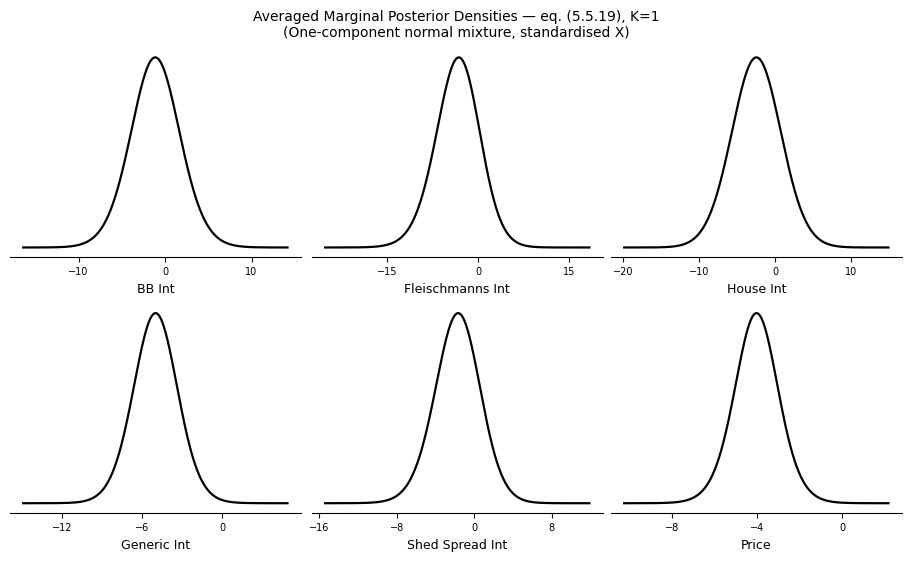

In [94]:
# ── 4. Plot — Figure 5.6 style ────────────────────────────────────────────────
 
plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]
 
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(9, 5.5),
    constrained_layout=True
)
 
for idx, ax in enumerate(axes.flat):
    ax.plot(grids[idx], densities[idx], color='black', linewidth=1.6)
 
    ax.set_xlabel(plot_labels[idx], fontsize=9)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=False))
 
fig.suptitle(
    'Averaged Marginal Posterior Densities — eq. (5.5.19), K=1\n'
    '(One-component normal mixture, standardised X)',
    fontsize=10
)
 
plt.show()

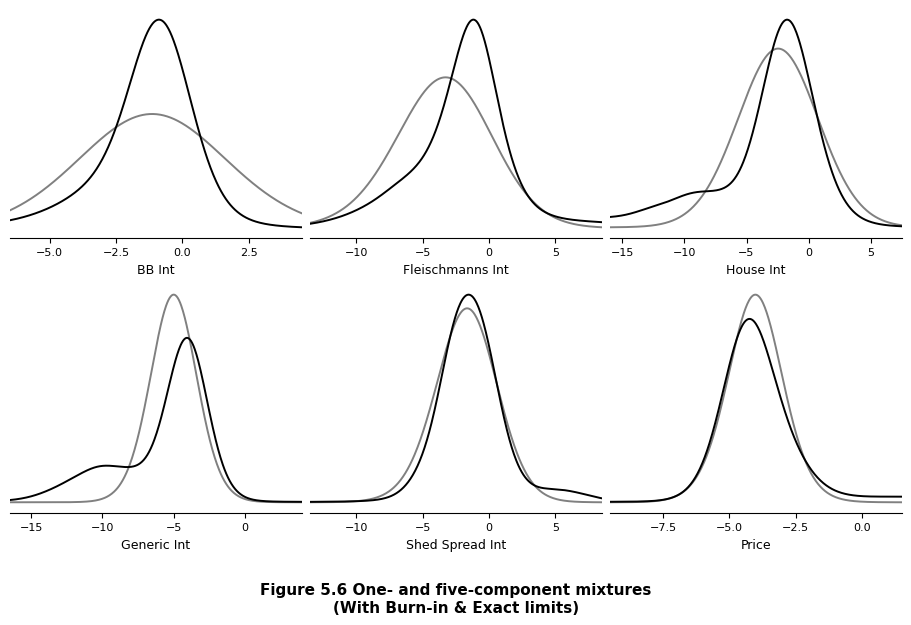

In [95]:
# ==============================================================================
# Margarine Hierarchical MNL — One- and Five-Component Mixtures
# 
# Overlays the 1-component (grey) and 5-component (black) marginal densities.
# - Discards the first 30% of draws as burn-in for tighter distributions.
# - Strictly enforces the x-axis limits from Figure 5.6 of the paper.
# ==============================================================================
 
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

# ── 1. Hardcoded intervals matching the visual margins in Figure 5.6 ─────────
paper_limits = [
    (-6.5, 4.5),   # BB Int
    (-13.5, 8.5),  # Fleischmanns Int
    (-16.0, 7.5),  # House Int
    (-16.5, 4.0),  # Generic Int
    (-13.5, 8.5),  # Shed Spread Int
    (-9.5, 1.5)    # Price
]

plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]

nvar = 6
N_GRID = 500
BURN_IN_FRAC = 0.30  # Discard the first 30% of draws

# ── 2. Load 1-Component Data (with Burn-in) ───────────────────────────────────
data_path_1 = pathlib.Path('Data') / 'bayesm_output_margarine_1comp_rawX.RData'
rdata_1  = pyreadr.read_r(str(data_path_1))

R_total_1 = rdata_1['mu_draws_df'].shape[0]
burn_in_1 = int(R_total_1 * BURN_IN_FRAC)

mu_1  = rdata_1['mu_draws_df'].values.astype(float)[burn_in_1:, :]   # (R_kept, 6)
cov_1 = rdata_1['cov_draws_df'].values.astype(float)[burn_in_1:, :]  # (R_kept, 36)

# Extract diagonal (variances) for K=1
diag_idx_1 = np.array([j * nvar + j for j in range(nvar)])  
std_1 = np.sqrt(cov_1[:, diag_idx_1]) # (R_kept, 6)

# ── 3. Load 5-Component Data (with Burn-in) ───────────────────────────────────
data_path_5 = pathlib.Path('Data') / 'bayesm_output_margarine_5comp_rawX.RData'
rdata_5  = pyreadr.read_r(str(data_path_5))

R_total_5 = rdata_5['mu_draws_df'].shape[0]
burn_in_5 = int(R_total_5 * BURN_IN_FRAC)

pvec_5 = rdata_5['pvec_draws_df'].values.astype(float)[burn_in_5:, :] # (R_kept, 5)
mu_5   = rdata_5['mu_draws_df'].values.astype(float)[burn_in_5:, :]   # (R_kept, 30)
cov_5  = rdata_5['cov_draws_df'].values.astype(float)[burn_in_5:, :]  # (R_kept, 180)

# ── 4. Evaluate Densities for both K=1 and K=5 ───────────────────────────────
grids = []
densities_1 = []
densities_5 = []
 
for j in range(nvar):
    # Setup grid strictly using the paper's limits
    lo, hi = paper_limits[j]
    x = np.linspace(lo, hi, N_GRID)
    grids.append(x)

    # --- Evaluate 1-Component (K=1) ---
    mu_1_j = mu_1[:, j]
    std_1_j = std_1[:, j]
    
    pdf_1 = norm.pdf(x[:, None], loc=mu_1_j[None, :], scale=std_1_j[None, :])
    densities_1.append(pdf_1.mean(axis=1))

    # --- Evaluate 5-Component (K=5) ---
    mu_idx_5  = [j + k * nvar for k in range(5)]
    cov_idx_5 = [k * (nvar * nvar) + (j * nvar + j) for k in range(5)]
    
    mu_5_j  = mu_5[:, mu_idx_5]              
    std_5_j = np.sqrt(cov_5[:, cov_idx_5])   
    
    pdf_5 = norm.pdf(
        x[:, None, None],          
        loc=mu_5_j[None, :, :],   
        scale=std_5_j[None, :, :] 
    ) 
    
    # Multiply by mixture probabilities and sum components
    weighted_pdf_5 = pdf_5 * pvec_5[None, :, :]
    mixture_density = weighted_pdf_5.sum(axis=2)
    densities_5.append(mixture_density.mean(axis=1))

# ── 5. Plotting (Figure 5.6 Style) ────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(9, 5.5),
    constrained_layout=True
)
 
for idx, ax in enumerate(axes.flat):
    # Plot K=1 in grey
    ax.plot(grids[idx], densities_1[idx], color='grey', linewidth=1.4)
    # Plot K=5 in black
    ax.plot(grids[idx], densities_5[idx], color='black', linewidth=1.4)
 
    ax.set_xlabel(plot_labels[idx], fontsize=9)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)
    
    # Strictly enforce the exact paper limits on the visual axes
    ax.set_xlim(paper_limits[idx])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=False))
 
fig.suptitle(
    'Figure 5.6 One- and five-component mixtures\n(With Burn-in & Exact limits)',
    fontsize=11, fontweight='bold', y=-0.05
)
 
plt.show()

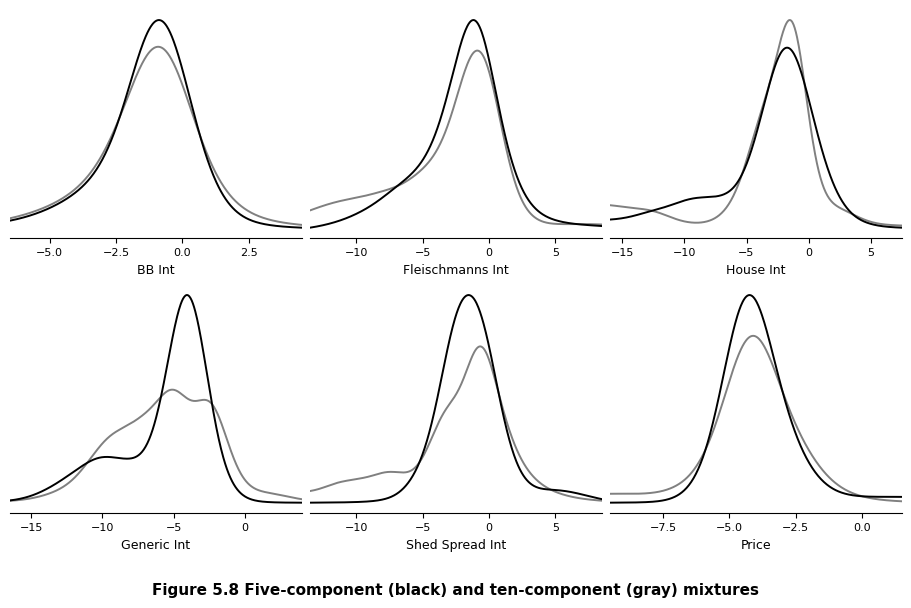

In [96]:
# ==============================================================================
# Margarine Hierarchical MNL — Figure 5.8
# 
# Overlays the 5-component (black) and 10-component (gray) marginal densities.
# - Discards the first 30% of draws as burn-in.
# - Strictly enforces the x-axis limits from the paper.
# ==============================================================================
 
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

# ── 1. Hardcoded intervals matching the visual margins in the paper ───────────
paper_limits = [
    (-6.5, 4.5),   # BB Int
    (-13.5, 8.5),  # Fleischmanns Int
    (-16.0, 7.5),  # House Int
    (-16.5, 4.0),  # Generic Int
    (-13.5, 8.5),  # Shed Spread Int
    (-9.5, 1.5)    # Price
]

plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]

nvar = 6
N_GRID = 500
BURN_IN_FRAC = 0.30  # Discard the first 30% of draws

# ── 2. Load 5-Component Data ──────────────────────────────────────────────────
data_path_5 = pathlib.Path('Data') / 'bayesm_output_margarine_5comp_rawX.RData'
rdata_5  = pyreadr.read_r(str(data_path_5))

R_total_5 = rdata_5['mu_draws_df'].shape[0]
burn_in_5 = int(R_total_5 * BURN_IN_FRAC)

pvec_5 = rdata_5['pvec_draws_df'].values.astype(float)[burn_in_5:, :] 
mu_5   = rdata_5['mu_draws_df'].values.astype(float)[burn_in_5:, :]   
cov_5  = rdata_5['cov_draws_df'].values.astype(float)[burn_in_5:, :]  

# ── 3. Load 10-Component Data ─────────────────────────────────────────────────
data_path_10 = pathlib.Path('Data') / 'bayesm_output_margarine_10comp_rawX.RData'
rdata_10  = pyreadr.read_r(str(data_path_10))

R_total_10 = rdata_10['mu_draws_df'].shape[0]
burn_in_10 = int(R_total_10 * BURN_IN_FRAC)

pvec_10 = rdata_10['pvec_draws_df'].values.astype(float)[burn_in_10:, :] 
mu_10   = rdata_10['mu_draws_df'].values.astype(float)[burn_in_10:, :]   
cov_10  = rdata_10['cov_draws_df'].values.astype(float)[burn_in_10:, :]  

# ── 4. Evaluate Densities for both K=5 and K=10 ──────────────────────────────
grids = []
densities_5 = []
densities_10 = []
 
for j in range(nvar):
    # Setup grid strictly using the paper's limits
    lo, hi = paper_limits[j]
    x = np.linspace(lo, hi, N_GRID)
    grids.append(x)

    # --- Evaluate 5-Component (K=5) ---
    mu_idx_5  = [j + k * nvar for k in range(5)]
    cov_idx_5 = [k * (nvar * nvar) + (j * nvar + j) for k in range(5)]
    
    mu_5_j  = mu_5[:, mu_idx_5]              
    std_5_j = np.sqrt(cov_5[:, cov_idx_5])   
    
    pdf_5 = norm.pdf(x[:, None, None], loc=mu_5_j[None, :, :], scale=std_5_j[None, :, :]) 
    weighted_pdf_5 = pdf_5 * pvec_5[None, :, :]
    mixture_density_5 = weighted_pdf_5.sum(axis=2)
    densities_5.append(mixture_density_5.mean(axis=1))

    # --- Evaluate 10-Component (K=10) ---
    mu_idx_10  = [j + k * nvar for k in range(10)]
    cov_idx_10 = [k * (nvar * nvar) + (j * nvar + j) for k in range(10)]
    
    mu_10_j  = mu_10[:, mu_idx_10]              
    std_10_j = np.sqrt(cov_10[:, cov_idx_10])   
    
    pdf_10 = norm.pdf(x[:, None, None], loc=mu_10_j[None, :, :], scale=std_10_j[None, :, :]) 
    weighted_pdf_10 = pdf_10 * pvec_10[None, :, :]
    mixture_density_10 = weighted_pdf_10.sum(axis=2)
    densities_10.append(mixture_density_10.mean(axis=1))

# ── 5. Plotting (Figure 5.8 Style) ────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(9, 5.5),
    constrained_layout=True
)
 
for idx, ax in enumerate(axes.flat):
    # Plot K=10 in gray (background)
    ax.plot(grids[idx], densities_10[idx], color='gray', linewidth=1.4)
    # Plot K=5 in black (foreground)
    ax.plot(grids[idx], densities_5[idx], color='black', linewidth=1.4)
 
    ax.set_xlabel(plot_labels[idx], fontsize=9)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)
    
    # Strictly enforce the exact paper limits on the visual axes
    ax.set_xlim(paper_limits[idx])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=False))
 
fig.suptitle(
    'Figure 5.8 Five-component (black) and ten-component (gray) mixtures',
    fontsize=11, fontweight='bold', y=-0.05
)
 
plt.show()